# Lab 4: Compare RNN vs LSTM vs GRU Performance
This notebook builds and compares Simple RNN, LSTM, and GRU models on the IMDB text classification dataset.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Load and Prepare Dataset

In [2]:
max_features = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: 25000


## Build Models

In [3]:
def build_model(model_type):
    model = keras.Sequential()
    model.add(layers.Embedding(max_features, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(layers.SimpleRNN(128))
    elif model_type == "LSTM":
        model.add(layers.LSTM(128))
    elif model_type == "GRU":
        model.add(layers.GRU(128))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

## Train Models

In [4]:
models = {}
histories = {}

for model_name in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_name}...")
    model = build_model(model_name)
    history = model.fit(x_train, y_train,
                        epochs=3,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)
    models[model_name] = model
    histories[model_name] = history


Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 136ms/step - accuracy: 0.5696 - loss: 0.6704 - val_accuracy: 0.6160 - val_loss: 0.6386
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.7264 - loss: 0.5387 - val_accuracy: 0.6480 - val_loss: 0.6113
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 136ms/step - accuracy: 0.8122 - loss: 0.4182 - val_accuracy: 0.8034 - val_loss: 0.4563

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 161s 509ms/step - accuracy: 0.7679 - loss: 0.4730 - val_accuracy: 0.8582 - val_loss: 0.3516
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 511ms/step - accuracy: 0.8817 - loss: 0.2912 - val_accuracy: 0.8626 - val_loss: 0.3202
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 509ms/step - accuracy: 0.9225 - loss: 0.2013 - val_accuracy: 0.8464 - val_loss: 0.3530

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 163s 514ms/step - accuracy: 0.7473 - loss: 0.4936 - val_accuracy: 0.7990 - val_loss: 0.4462
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 202s 514ms/step - accu

## Evaluate Models

In [5]:
results = {}

for model_name, model in models.items():
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    results[model_name] = acc
    print(f"{model_name} Test Accuracy: {acc:.4f}")

RNN Test Accuracy: 0.7952
LSTM Test Accuracy: 0.8498
GRU Test Accuracy: 0.8708


## Accuracy Comparison Plot

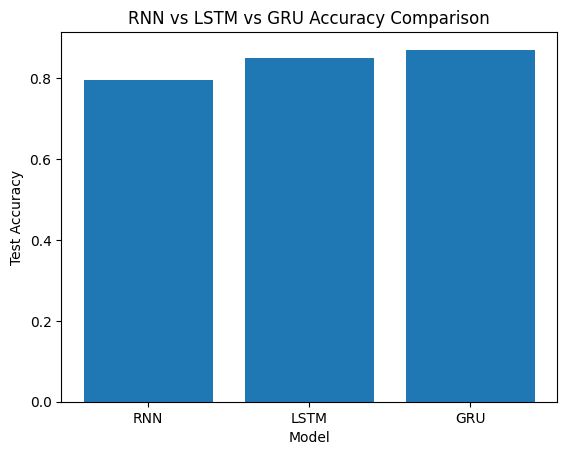

In [6]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN vs LSTM vs GRU Accuracy Comparison")
plt.show()

## Conclusion
- Simple RNN suffers from vanishing gradient problem.
- LSTM handles long-term dependencies using gates.
- GRU is computationally efficient and often performs similar to LSTM.

Typically: LSTM ≈ GRU > RNN in text classification tasks.